##### Ссылка на репозиторий и этот ноутбук с файлами: github: https://github.com/randnull/genotec/blob/main/hw_2_pca.ipynb

Домашнее задание 2

После установки [plink 1.9](https://www.cog-genomics.org/plink/) и скачивания файла с геномами (папка data) c http://www.russiangenome.ru/ выполнил команды

1. LD-pruning

Возьмем размер окна 50, шаг в 5, а порог $r^2$=0.2

```bash
plink --bfile biengi/biengi --indep-pairwise 50 5 0.2 --out data/biengi_pruned
```

Теперь наши данные очищены от избыточности для корректного PCA

По выходе мы получаем 3 файла:
- логи 
- *.prune.in (то, что мы оставляем)
- *.prune.out (то, что изыточно)

2. Очистим оригинальный файл и создадим версию без избыточности:

```bash
plink --bfile biengi/biengi --extract biengi_pruned.prune.in --make-bed --out biengi_ldpruned
```

3. Теперь проводим PCA (берем первые 5 главных компонент)

```bash
plink --bfile biengi_ldpruned --pca 5 --out biengi_pca
```

По выходе получаем файл *.eigenval (собственные векторы, координаты людей по главным компонентам) и *.eigenvec - (собственные значения, "сколько вариации объясняет каждая компонента")

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import matplotlib.colors as mcolors

In [50]:
df = pd.read_csv("data/biengi_pca.eigenvec", sep=" ", header=None)

In [51]:
df = df.drop(columns=[0]) 
df.columns = ["ID", "PCA1", "PCA2", "PCA3", "PCA4", "PCA5"]

Посмотрим на данные:

In [52]:
df

,ID,PCA1,PCA2,PCA3,PCA4,PCA5
0,4461875510_R01C01,0.023268,0.045263,0.022689,0.010318,-0.010266
1,4461875510_R01C02,0.029193,0.033087,0.032917,0.010460,-0.009539
2,4461875510_R02C01,0.026054,0.043777,0.023756,0.007279,-0.005754
3,4461875513_R02C02,0.022733,0.046444,0.025356,0.013972,-0.011478
4,4461875513_R01C02,0.024085,0.043039,0.016676,0.008785,-0.005823
...,...,...,...,...,...,...
889,4252441600_B,-0.063573,-0.009692,0.023188,0.017268,-0.125835
890,4252441601_A,-0.065558,-0.009399,0.026678,0.014877,-0.141641
891,4252441601_B,-0.060814,-0.005724,0.012487,0.009106,-0.082966
892,4252441619_A,-0.055805,-0.005282,0.028275,0.015013,-0.124027


Тут есть ID и значения по главным компонентам.

В табличу также нужно добавить данные о происхождении для каждого человека

In [53]:
with open("data/biengi/biengi.pedind") as f:
    pedind_file = f.readlines()


In [54]:
mapping = dict()
for person in pedind_file:
    sample = person.split('\t')
    mapping[sample[1]] = sample[-1][:-1]


In [55]:
df["nationality"] = df["ID"].map(mapping)

In [56]:
df

,ID,PCA1,PCA2,PCA3,PCA4,PCA5,nationality
0,4461875510_R01C01,0.023268,0.045263,0.022689,0.010318,-0.010266,Karel
1,4461875510_R01C02,0.029193,0.033087,0.032917,0.010460,-0.009539,Karel
2,4461875510_R02C01,0.026054,0.043777,0.023756,0.007279,-0.005754,Karel
3,4461875513_R02C02,0.022733,0.046444,0.025356,0.013972,-0.011478,Karel
4,4461875513_R01C02,0.024085,0.043039,0.016676,0.008785,-0.005823,Karel
...,...,...,...,...,...,...,...
889,4252441600_B,-0.063573,-0.009692,0.023188,0.017268,-0.125835,Yakut
890,4252441601_A,-0.065558,-0.009399,0.026678,0.014877,-0.141641,Yakut
891,4252441601_B,-0.060814,-0.005724,0.012487,0.009106,-0.082966,Yakut
892,4252441619_A,-0.055805,-0.005282,0.028275,0.015013,-0.124027,Yakut


In [57]:
def get_color_by_ids(nationalities):
    nat_clean = list(set(nationalities))
    colors = np.linspace(0, 1, len(nat_clean))
    color_by_id = dict(zip(nat_clean, colors))
    out = [color_by_id[id] for id in nationalities]
    return out, color_by_id


Теперь выведем все возможные комбинации PCA на графике:

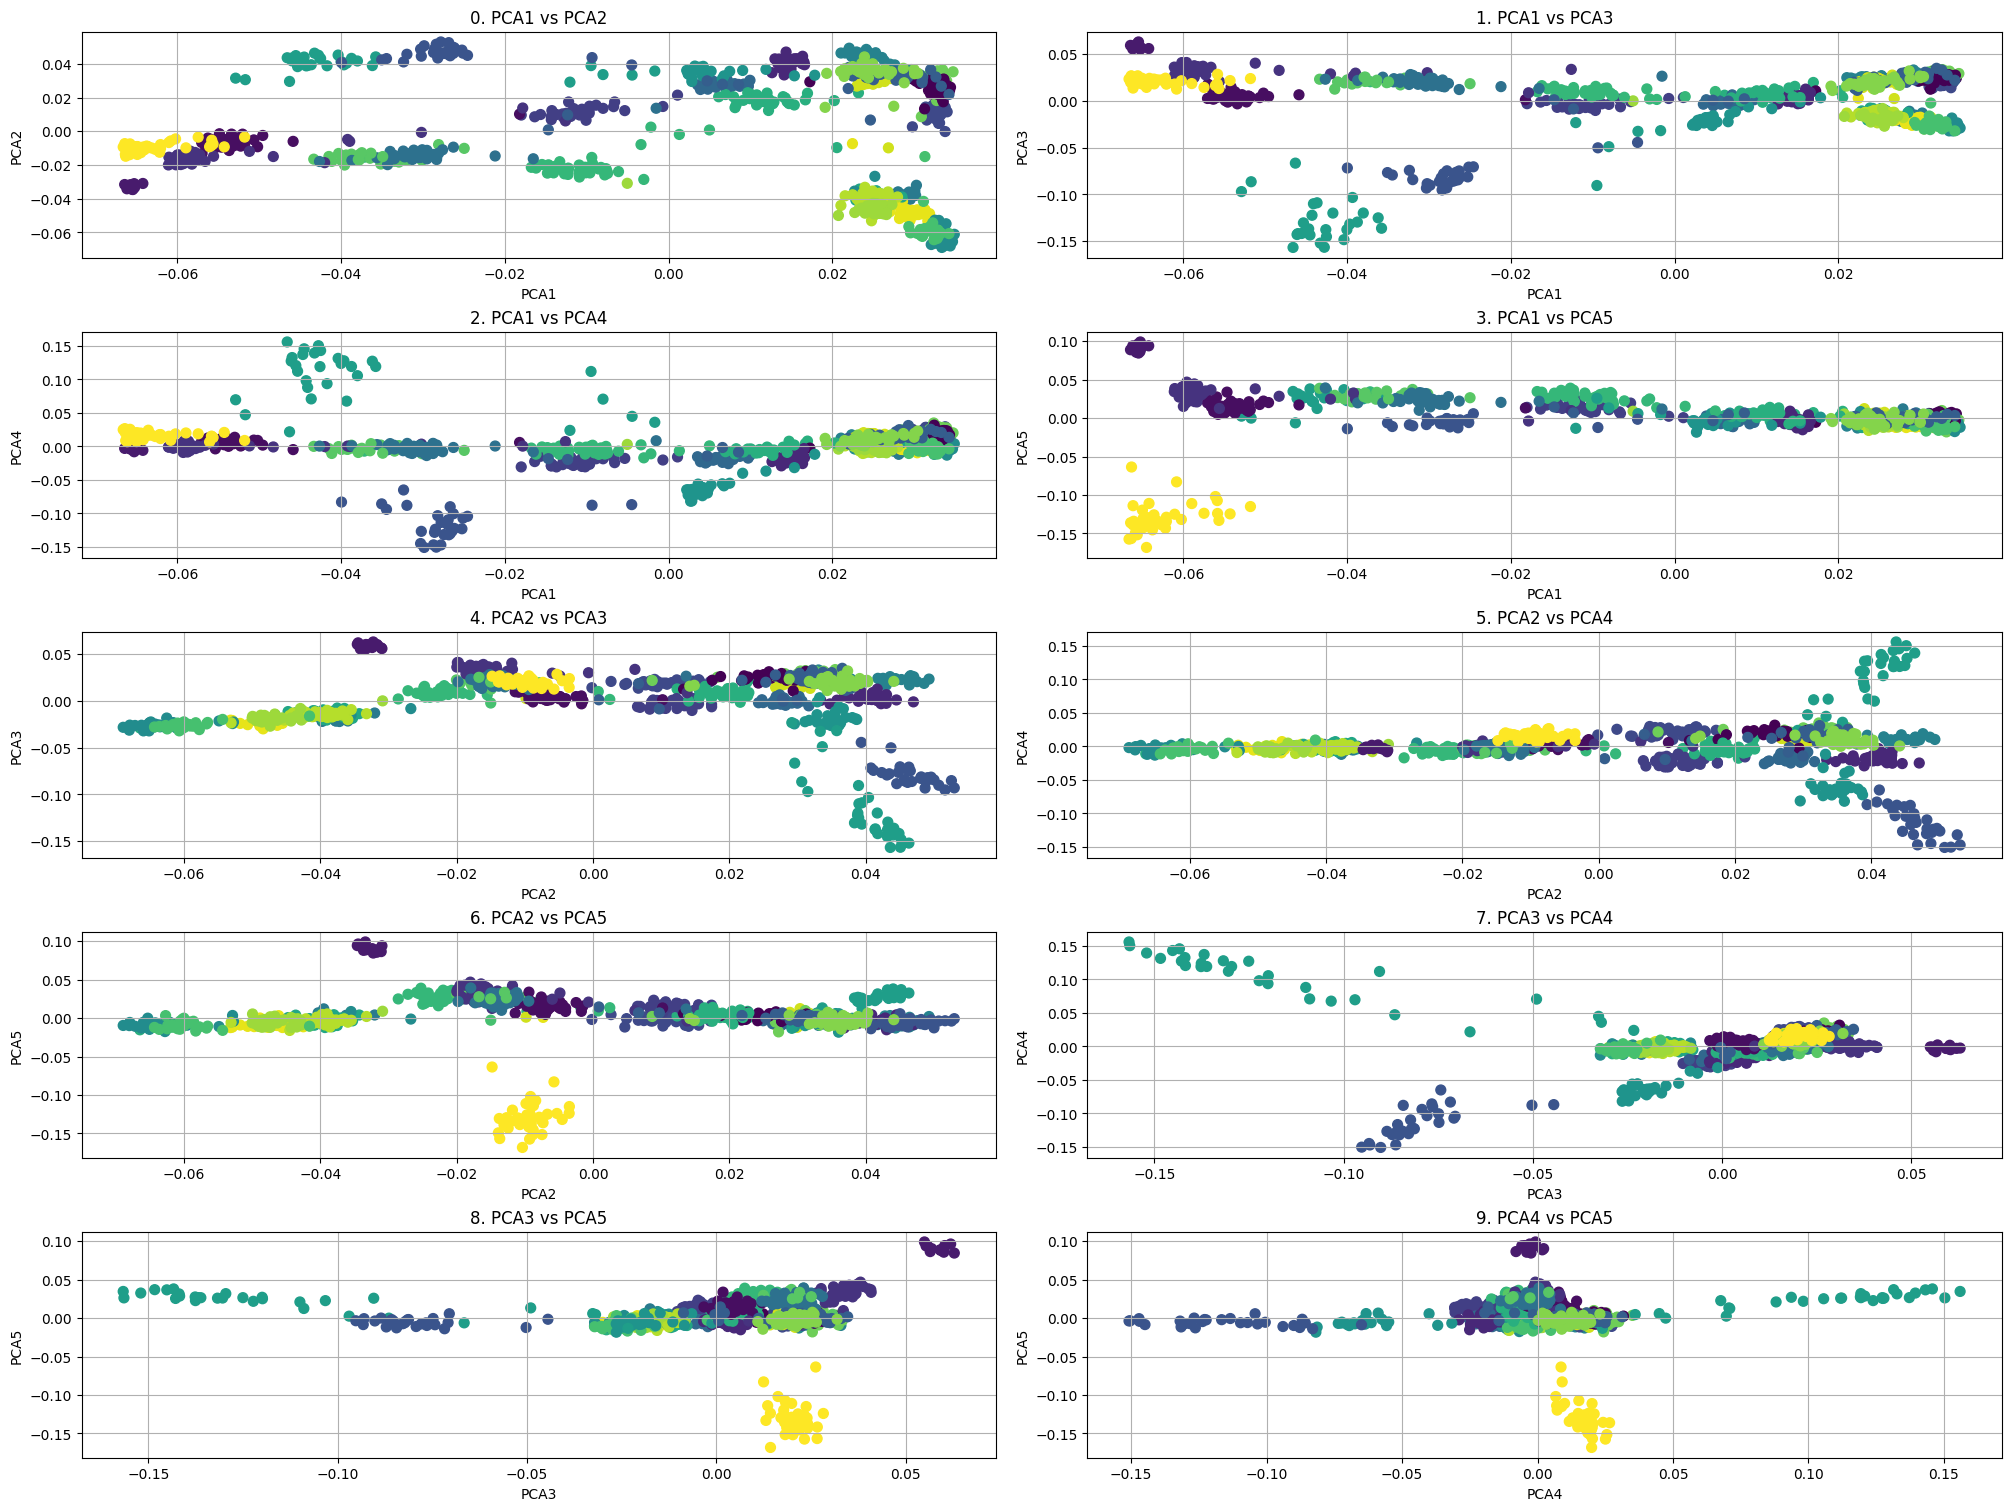

In [58]:
fig, axs = plt.subplots(5, 2, layout='constrained', figsize=(20, 15))

axs_flat = axs.flatten()

pca_list = list(df.columns)[1:-1]

colors, color_by_id = get_color_by_ids(df['nationality'])

for i, pcas in enumerate(combinations(pca_list, r=2)):
    pca_l, pca_r = pcas
    axs_flat[i].scatter(df[pca_l], df[pca_r], c=colors, cmap='viridis', s=50)
    axs_flat[i].set_title(f'{i}. {pca_l} vs {pca_r}')
    axs_flat[i].set_xlabel(pca_l)
    axs_flat[i].set_ylabel(pca_r)
    axs_flat[i].grid(True)

Отдельно рассмотрим PCA1 vs PCA2

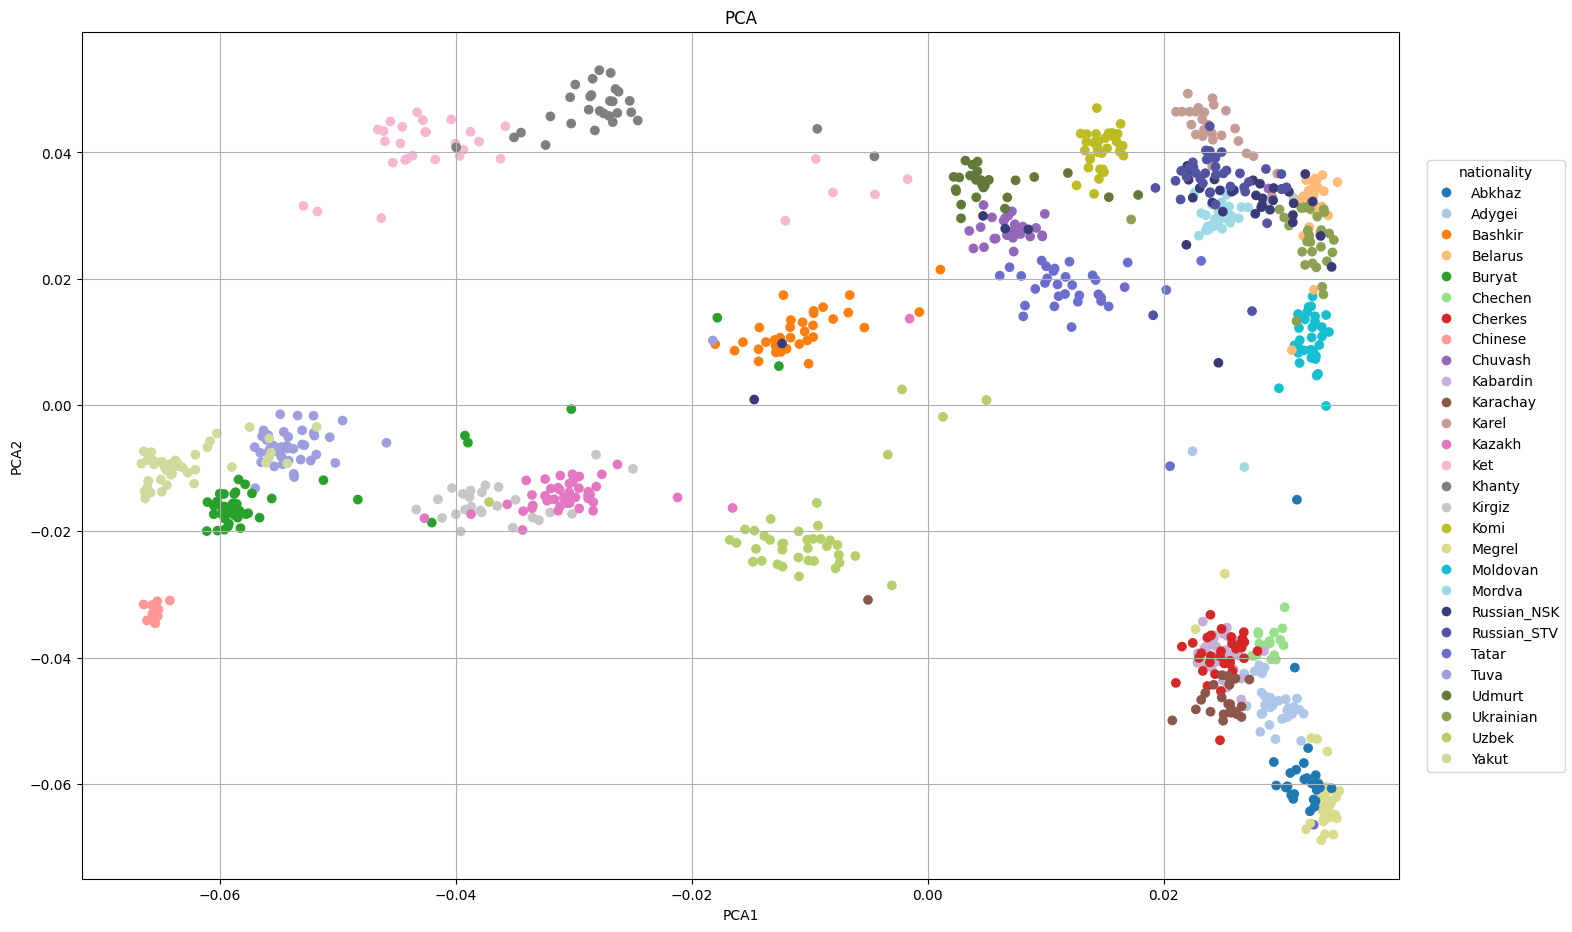

In [59]:
def make_categorical_palette(n):
    colors = []
    for cmap_name in ["tab20", "tab20b", "tab20c"]:
        cmap = plt.get_cmap(cmap_name)
        colors.extend([cmap(i) for i in range(cmap.N)])
    return colors[:n]

nat_unique = sorted(df["nationality"].dropna().unique())
nat_to_code = {nat: i for i, nat in enumerate(nat_unique)}
df["nat_code"] = df["nationality"].map(nat_to_code)

palette = make_categorical_palette(len(nat_unique))
cmap = mcolors.ListedColormap(palette)

fig = plt.figure(figsize=(17, 11))
plt.scatter(df["PCA1"], df["PCA2"], c=df["nat_code"], cmap=cmap)
plt.grid(True)
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("PCA")

handles = []
for i, nat in enumerate(nat_unique):
    handles.append(
        plt.Line2D(
            [0], [0],
            marker='o',
            color='w',
            label=nat,
            markerfacecolor=palette[i],
            markersize=8
    )
)

fig.legend(handles=handles, title="nationality", loc="center right")
plt.show()

Наблюдается ли кластеризация популяции?
Соответствует ли расположение популцяций ожиданиям исходя из их географического
распространения?

Да, явно наблюдается кластеризация популяций по группам (точки (люди) одного цвета (национальности) расположены близко к друг другу).

Расположение соответствует географическому расположению:

Например видно, что популяции из Казахстана и Кыргызстана (розовые и серые) близки друг к другу (как и на географической карте)

В другом месте (справа сверху) русские и белорусы также находятся вместе.